# Housing Recommendation System

## `PreProcessing`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_rows',100)

In [ ]:
df = pd.read_csv('housing.csv')

In [ ]:
df.head()

,url,image_url,Unnamed: 2,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,...,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,Unnamed: 40,price
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,NaN,3.0,2.0,"1,415","5,001 sqft","197 Lowell St, Arlington, MA 02474","$6,225/mo",single family,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,NaN,"$999,000"
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,NaN,2.0,1.0,"1,064","4,818 sqft","225 Mystic St, Arlington, MA 02474","$4,978/mo",single family,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",yes,NaN,NaN,"$799,000"
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,NaN,2.0,1.0,"1,628","7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474","$5,603/mo",single family,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,NaN,"$899,000"
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,NaN,3.0,2.0,"1,824","6,037 sqft","11 Pine Ct, Arlington, MA 02476","$6,219/mo",single family,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,NaN,"$998,000"
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,NaN,2.0,2.0,"1,221",NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474","$4,339/mo",condo,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",yes,NaN,NaN,"$668,000"


In [ ]:
df.shape

(8983, 42)

In [ ]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 40'], inplace=True)

In [ ]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,...,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,"1,415","5,001 sqft","197 Lowell St, Arlington, MA 02474","$6,225/mo",single family,$706/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,"$999,000"
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,"1,064","4,818 sqft","225 Mystic St, Arlington, MA 02474","$4,978/mo",single family,$751/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",yes,NaN,"$799,000"
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,"1,628","7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474","$5,603/mo",single family,$552/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,"$899,000"
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,"1,824","6,037 sqft","11 Pine Ct, Arlington, MA 02476","$6,219/mo",single family,$547/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,"$998,000"
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,"1,221",NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474","$4,339/mo",condo,$547/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",yes,NaN,"$668,000"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         8983 non-null   object 
 1   image_url                   8983 non-null   object 
 2   beds                        8594 non-null   float64
 3   baths                       8893 non-null   float64
 4   sqft                        8589 non-null   object 
 5   sqft_lot                    6591 non-null   object 
 6   address                     8950 non-null   object 
 7   estimated_monthly_payment   8834 non-null   object 
 8   property_type               8983 non-null   object 
 9   price_per_sqft              8649 non-null   object 
 10  year_built                  8667 non-null   float64
 11  region                      8983 non-null   object 
 12  interior_features           8951 non-null   object 
 13  other_rooms                 8981 

In [ ]:
df.isna().sum()

,0
url,0
image_url,0
beds,389
baths,90
sqft,394
sqft_lot,2392
address,33
estimated_monthly_payment,149
property_type,0
price_per_sqft,334


# Cleaning


`price`
1. Remove $ sign
2. Remove , sign
3. convert the column to int dtype

In [ ]:
df['price'].isna().sum()

np.int64(0)

In [ ]:
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')

In [ ]:
df['price'].sample(10)

,price
6,699900
7562,579000
4092,299900
4968,1050000
7169,799500
2944,1100000
3145,899000
5526,499900
7076,630000
2335,11249500


In [ ]:
df['price'] = df['price'].astype('int')

In [ ]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,...,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,"1,415","5,001 sqft","197 Lowell St, Arlington, MA 02474","$6,225/mo",single family,$706/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,"1,064","4,818 sqft","225 Mystic St, Arlington, MA 02474","$4,978/mo",single family,$751/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",yes,NaN,799000
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,"1,628","7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474","$5,603/mo",single family,$552/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,"1,824","6,037 sqft","11 Pine Ct, Arlington, MA 02476","$6,219/mo",single family,$547/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,"1,221",NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474","$4,339/mo",condo,$547/sqft,...,Minimal (1/10),Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",yes,NaN,668000


`url` :   
1. delete this land (it's not a house) : https://www.zillow.com/homedetails/32-Providence-St-Rehoboth-MA-02769/123745409_zpid/

2. this is a storage : https://www.zillow.com/homedetails/0-Wilcox-St-Fall-River-MA-02724/2062036299_zpid/

3. remove this : https://www.zillow.com/homedetails/993-Williamsburg-Cir-Warwick-RI-02886/65859082_zpid/



In [ ]:
remove_rows = ['https://www.zillow.com/homedetails/32-Providence-St-Rehoboth-MA-02769/123745409_zpid/','https://www.zillow.com/homedetails/0-Wilcox-St-Fall-River-MA-02724/2062036299_zpid/','https://www.zillow.com/homedetails/993-Williamsburg-Cir-Warwick-RI-02886/65859082_zpid/']

In [ ]:
df['baths'].isna().sum()

np.int64(90)

In [ ]:
df[df['url'] == 'https://www.zillow.com/homedetails/32-Providence-St-Rehoboth-MA-02769/123745409_zpid/']

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,...,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price
221,https://www.zillow.com/homedetails/32-Providen...,https://photos.zillowstatic.com/fp/da59065a866...,NaN,0.0,NaN,7.227 Acres,"32 Providence St, Rehoboth, MA 02769","$2,680/mo",condo,NaN,...,NaN,Moderate (3/10),Major (6/10),Minor (2/10),Major (5/10),Attleboro; Dartmouth; Easton; Fall River; Mans...,"{'date': '7/21/2025', 'event': 'Listed for sal...",NaN,NaN,139000


No more need to clean the url because url is not gonna be used as a part of training feature

Same for image url

In [ ]:
df['beds'].isna().sum()

np.int64(389)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         8983 non-null   object 
 1   image_url                   8983 non-null   object 
 2   beds                        8594 non-null   float64
 3   baths                       8893 non-null   float64
 4   sqft                        8589 non-null   object 
 5   sqft_lot                    6591 non-null   object 
 6   address                     8950 non-null   object 
 7   estimated_monthly_payment   8834 non-null   object 
 8   property_type               8983 non-null   object 
 9   price_per_sqft              8649 non-null   object 
 10  year_built                  8667 non-null   float64
 11  region                      8983 non-null   object 
 12  interior_features           8951 non-null   object 
 13  other_rooms                 8981 

In [ ]:
df['sqft'].isna().sum()

np.int64(394)

In [ ]:
df['sqft'] = df['sqft'].str.replace(',','')

In [ ]:
df['sqft'] = df['sqft'].astype('float')

In [ ]:
df['sqft'].dtype

dtype('float64')

In [ ]:
df['sqft_lot'].sample(30)

,sqft_lot
7759,10.05 Acres
6301,NaN
8757,", sqft"
3696,NaN
2409,13 sqft
3295,2 sqft
1358,"4,000 sqft"
1339,1.13 Acres
8900,22.14 Acres
930,0.39 sqft


In [ ]:
df['sqft_lot'].isna().sum()

np.int64(2392)

In [79]:
df.iloc[3295]['url']

'https://www.zillow.com/homedetails/2A-Bodfish-Ave-Sandwich-MA-02563/55924605_zpid/'

converting the data from sqft to acres

once this is done, -> categorize it to small medium large  extreme large.. because if we have just the numbers, it will have a lot of outliers

In [205]:
def convert_sqft_lot(val):
    def sqft_lot_value_convert(value):
        value = str(value).lower()
        if 'acres' in value:
            num = re.findall(r'\d+\.?\d*', value)
            if num:
                num_float = float(num[0])
                return num_float * 43560
            else:
                return None
        else:
            num = re.findall(r'\d+\.?\d*', value)
            if num:
                return float(num[0])
            else:
                return None

    def categorize_lot_size(sqft):
        if sqft is None:       # Handle None values
            return 'Unknown'
        elif sqft < 2000:
            return 'Ultra Compact'
        elif sqft < 4000:
            return 'Urban Small'
        elif sqft < 7000:
            return 'Urban Medium'
        elif sqft < 12000:
            return 'Suburban Small'
        elif sqft < 25000:
            return 'Suburban Medium'
        elif sqft < 43560:
            return 'Suburban Large'
        else:
            return 'Rural/Estate'

    final_val = sqft_lot_value_convert(val)
    return categorize_lot_size(final_val)

In [219]:
df['sqft_lot_caterogy'] = df['sqft_lot'].apply(convert_sqft_lot)

In [220]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,...,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474","$6,225/mo",single family,$706/sqft,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474","$4,978/mo",single family,$751/sqft,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",yes,NaN,799000,Ultra Compact
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474","$5,603/mo",single family,$552/sqft,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476","$6,219/mo",single family,$547/sqft,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474","$4,339/mo",condo,$547/sqft,...,Minimal (1/10),Major (6/10),Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",yes,NaN,668000,Unknown


In [222]:
df['sqft_lot_caterogy'].value_counts()

,count
sqft_lot_caterogy,
Ultra Compact,2567
Unknown,2471
Rural/Estate,1721
Suburban Medium,1324
Suburban Large,743
Suburban Small,157


keeping both formats


In [223]:
def sqft_lot_value_convert(value):
    value = str(value).lower()
    if 'acres' in value:
        num = re.findall(r'\d+\.?\d*', value)
        if num:
            num_float = float(num[0])
            return num_float * 43560
        else:
            return None
    else:
        num = re.findall(r'\d+\.?\d*', value)
        if num:
            return float(num[0])
        else:
            return None

In [224]:
df['sqft_lot_cleaned'] = df['sqft_lot'].apply(sqft_lot_value_convert)

In [227]:
df.sample(10)

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,...,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned
6448,https://www.zillow.com/homedetails/3-S-Stone-M...,https://photos.zillowstatic.com/fp/24c6f7c6136...,2.0,2.0,1285.0,NaN,"3 S Stone Mill Dr APT 221, Dedham, MA 02026","$4,456/mo",condo,$396/sqft,...,Major (6/10),Minor (2/10),Major (6/10),Braintree; Brookline; Franklin; Needham; Norwood,"{'date': '4/30/2025', 'event': 'Listed for sal...",NaN,1.0,509000,Unknown,NaN
6623,https://www.zillow.com/homedetails/4-Arnold-Dr...,https://photos.zillowstatic.com/fp/4be5172127b...,2.0,2.0,1586.0,NaN,"4 Arnold Dr #C, Salem, MA 01970","$3,167/mo",townhouse,$277/sqft,...,Major (6/10),Moderate (3/10),Major (5/10),Andover; Beverly; Haverhill; Lawrence; Lynn,"{'date': '7/22/2025', 'event': 'Listed for sal...",yes,1.0,439000,Unknown,NaN
2912,https://www.zillow.com/homedetails/183-L-St-1-...,https://photos.zillowstatic.com/fp/0b282006aba...,2.0,2.0,1235.0,NaN,"183 L St #1, South Boston, MA 02127","$4,705/mo",condo,$606/sqft,...,Major (6/10),Moderate (3/10),Major (6/10),Boston; Chelsea; Revere; Winthrop,"{'date': '7/11/2025', 'event': 'Listed for sal...",yes,NaN,749000,Unknown,NaN
7800,https://www.zillow.com/homedetails/7-Reservoir...,https://photos.zillowstatic.com/fp/b4ffe86dfd9...,NaN,NaN,NaN,0.34 sqft,"7 Reservoir Heights Rd, Otis, MA 01253","$5,161/mo",single family,$522/sqft,...,Moderate (4/10),Minor (2/10),Minor (2/10),Adams; Cheshire; Dalton; Great Barrington; Lee,"{'date': '7/8/2025', 'event': 'Price change', ...",yes,NaN,799900,Ultra Compact,0.34
1181,https://www.zillow.com/homedetails/3-Chipmunk-...,https://photos.zillowstatic.com/fp/c1fb9ab37e3...,2.0,1.0,806.0,NaN,"3 Chipmunk Trl UNIT 3, Westford, MA 01886","$2,083/mo",condo,$310/sqft,...,Major (6/10),Minor (2/10),Moderate (4/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/16/2025', 'event': 'Price change',...",yes,NaN,249900,Unknown,NaN
6171,https://www.zillow.com/homedetails/2-Minuteman...,https://photos.zillowstatic.com/fp/a2333840225...,5.0,5.0,5619.0,0.94 Acres,"2 Minuteman Rd, Medfield, MA 02052","$13,692/mo",single family,$391/sqft,...,Major (6/10),Minor (2/10),Major (5/10),Braintree; Brookline; Franklin; Needham; Norwood,"{'date': '7/9/2025', 'event': 'Listed for sale...",yes,3.0,2195000,Suburban Large,40946.40
5596,https://www.zillow.com/homedetails/131-Spruce-...,https://photos.zillowstatic.com/fp/d71473373a4...,5.0,3.0,2658.0,0.55 Acres,"131 Spruce St, Abington, MA 02351","$5,361/mo",single family,$319/sqft,...,Major (6/10),Minor (2/10),Major (5/10),Abington; Bridgewater; Brockton; Hingham; Mars...,"{'date': '7/9/2025', 'event': 'Listed for sale...",yes,3.0,849000,Suburban Medium,23958.00
4875,https://www.zillow.com/homedetails/110-Dilling...,https://photos.zillowstatic.com/fp/490e760027a...,2.0,2.0,1176.0,NaN,"110 Dillingham Ave UNIT 212, Falmouth, MA 02540","$4,777/mo",condo,$480/sqft,...,Severe (8/10),Moderate (3/10),Major (5/10),Barnstable; Bourne; Brewster; Chatham; Dennis,"{'date': '6/27/2025', 'event': 'Listed for sal...",NaN,1.0,564900,Unknown,NaN
8047,https://www.zillow.com/homedetails/9-Bolton-Dr...,https://photos.zillowstatic.com/fp/fbbb8b53f9b...,3.0,3.0,1764.0,0.39 Acres,"9 Bolton Dr, Lenox, MA 01240","$3,683/mo",single family,$323/sqft,...,Moderate (4/10),Minor (2/10),Minor (2/10),Adams; Cheshire; Dalton; Great Barrington; Lee,"{'date': '6/19/2025', 'event': 'Price change',...",NaN,2.0,569000,Suburban Medium,16988.40
8232,https://www.zillow.com/homedetails/62-Chase-Av...,https://photos.zillowstatic.com/fp/16db04878d6...,6.0,4.0,2522.0,NaN,"62 Chase Ave #64, North Adams, MA 01247","$1,237/mo",multi family,$75/sqft,...,Moderate (4/10),Minor (2/10),Moderate (3/10),Adams; Cheshire; Dalton; Great Barrington; Lee,"{'date': '7/21/2025', 'event': 'Listed for sal...",NaN,NaN,189000,Unknown,NaN


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         8983 non-null   object 
 1   image_url                   8983 non-null   object 
 2   beds                        8594 non-null   float64
 3   baths                       8893 non-null   float64
 4   sqft                        8589 non-null   float64
 5   sqft_lot                    6591 non-null   object 
 6   address                     8950 non-null   object 
 7   estimated_monthly_payment   8834 non-null   object 
 8   property_type               8983 non-null   object 
 9   price_per_sqft              8649 non-null   object 
 10  year_built                  8667 non-null   float64
 11  region                      8983 non-null   object 
 12  interior_features           8951 non-null   object 
 13  other_rooms                 8981 

<Axes: >

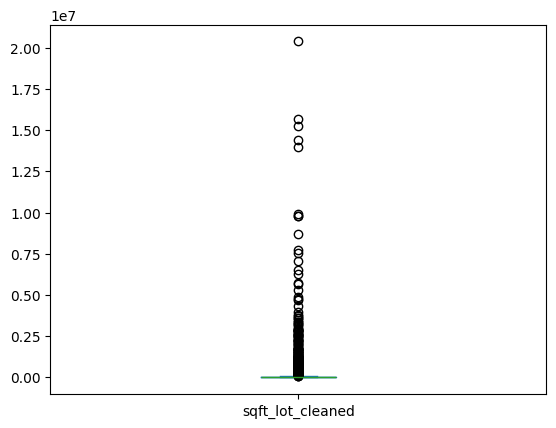

In [229]:
df['sqft_lot_cleaned'].plot(kind='box')

In [230]:
df.iloc[3043]

,3043
url,https://www.zillow.com/homedetails/3-Old-Barn-...
image_url,https://photos.zillowstatic.com/fp/1c8db434206...
beds,3.0
baths,2.0
sqft,2060.0
sqft_lot,0.46 Acres
address,"3 Old Barn Lane, Forestdale, MA 02644"
estimated_monthly_payment,"$3,940/mo"
property_type,single family
price_per_sqft,$323/sqft


extracting zip codes from address

In [231]:
df['address']

,address
0,"197 Lowell St, Arlington, MA 02474"
1,"225 Mystic St, Arlington, MA 02474"
2,"43 Longmeadow Rd, Arlington, MA 02474"
3,"11 Pine Ct, Arlington, MA 02476"
4,"17 Norcross St FLOOR 3, Arlington, MA 02474"
...,...
8978,"21 Mountainview St, Springfield, MA 01108"
8979,"7 East St, Springfield, MA 01104"
8980,"253 Stapleton Rd, Springfield, MA 01109"
8981,"1099 Parker St, Springfield, MA 01129"


In [274]:
# temp test
df['zip_code'] = df['address'].str.split('MA').str[1]

In [278]:
df['zip_code'] = df['zip_code'].astype('str')

In [279]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         8983 non-null   object 
 1   image_url                   8983 non-null   object 
 2   beds                        8594 non-null   float64
 3   baths                       8893 non-null   float64
 4   sqft                        8589 non-null   float64
 5   sqft_lot                    6591 non-null   object 
 6   address                     8950 non-null   object 
 7   estimated_monthly_payment   8834 non-null   object 
 8   property_type               8983 non-null   object 
 9   price_per_sqft              8649 non-null   object 
 10  year_built                  8667 non-null   float64
 11  region                      8983 non-null   object 
 12  interior_features           8951 non-null   object 
 13  other_rooms                 8981 

In [286]:
df['estimated_monthly_payment'] = df['estimated_monthly_payment'].str.replace(' monthly','/mo').str.replace('$','').str.replace('/mo','').str.replace(',','').astype('float')

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         8983 non-null   object 
 1   image_url                   8983 non-null   object 
 2   beds                        8594 non-null   float64
 3   baths                       8893 non-null   float64
 4   sqft                        8589 non-null   float64
 5   sqft_lot                    6591 non-null   object 
 6   address                     8950 non-null   object 
 7   estimated_monthly_payment   8834 non-null   float64
 8   property_type               8983 non-null   object 
 9   price_per_sqft              8649 non-null   object 
 10  year_built                  8667 non-null   float64
 11  region                      8983 non-null   object 
 12  interior_features           8951 non-null   object 
 13  other_rooms                 8981 

In [288]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,...,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225.0,single family,$706/sqft,...,Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5.0,02474
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978.0,single family,$751/sqft,...,Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",yes,NaN,799000,Ultra Compact,4.0,02474
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603.0,single family,$552/sqft,...,Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7.0,02474
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219.0,single family,$547/sqft,...,Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6.0,02476
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339.0,condo,$547/sqft,...,Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",yes,NaN,668000,Unknown,NaN,02474


In [289]:
df['property_type'].unique()

array(['single family', 'condo', 'townhouse', 'multi family',
       'Single Family', 'Condo', 'TOWNHOUSE'], dtype=object)

In [294]:
df['property_type'] = df['property_type'].str.lower()

In [295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8983 entries, 0 to 8982
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         8983 non-null   object 
 1   image_url                   8983 non-null   object 
 2   beds                        8594 non-null   float64
 3   baths                       8893 non-null   float64
 4   sqft                        8589 non-null   float64
 5   sqft_lot                    6591 non-null   object 
 6   address                     8950 non-null   object 
 7   estimated_monthly_payment   8834 non-null   float64
 8   property_type               8983 non-null   object 
 9   price_per_sqft              8649 non-null   object 
 10  year_built                  8667 non-null   float64
 11  region                      8983 non-null   object 
 12  interior_features           8951 non-null   object 
 13  other_rooms                 8981 

In [297]:
df['price_per_sqft'] = df['price_per_sqft'].str.replace('$','').str.replace('/sqft','')

In [301]:
df['price_per_sqft'] = df['price_per_sqft'].astype('float')

In [302]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,...,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225.0,single family,706.0,...,Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5.0,02474
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978.0,single family,751.0,...,Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",yes,NaN,799000,Ultra Compact,4.0,02474
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603.0,single family,552.0,...,Moderate (3/10),Major (5/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7.0,02474
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219.0,single family,547.0,...,Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6.0,02476
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339.0,condo,547.0,...,Moderate (3/10),Major (6/10),Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",yes,NaN,668000,Unknown,NaN,02474


In [305]:
df['year_built'] = df['year_built'].astype('Int64')

In [307]:
df['region'].value_counts()

,count
region,
Boston,455
Plymouth,252
Springfield,218
Cambridge,158
Newton,156
...,...
Sagaponack,1
Danielson,1
North Stonington,1
